<a href="https://colab.research.google.com/github/diyanrahma/Retrieval-Augmented-Generation-Automatic-Fact-Checking-PubHealth-Dataset/blob/main/Metode_Question_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2
!pip install transformers==4.37.2 datasets sentence-transformers accelerate

ERROR: Could not find a version that satisfies the requirement torch==2.1.2 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0)
ERROR: No matching distribution found for torch==2.1.2


In [ ]:
from transformers import AutoTokenizer
import pandas as pd
import re
import torch
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [ ]:
df_raw = pd.read_excel("/content/pubhealth_biomed_only.xlsx")
df_raw.head()

,id,claim,evidence,label,topic
0,2,SBRT Offers Prostate Cancer Patients High Canc...,This news release describes five-year outcomes...,mixture,Biomedis / Medis
1,3,"Study: Vaccine for Breast, Ovarian Cancer Has ...","While the story does many things well, the ove...",true,Biomedis / Medis
2,4,Some appendicitis cases may not require ’emerg...,We really don’t understand why only a handful ...,true,Biomedis / Medis
3,5,Britain to reveal trial criteria for coronavir...,British regulators will this week reveal appro...,true,Biomedis / Medis
4,7,U.S. says results encouraging for healthcare d...,The Obama administration on Thursday reported ...,true,Biomedis / Medis


In [ ]:
ds = df_raw.to_dict(orient="records")

In [ ]:
def norm(x):
    return {
        "id": x.get("id"),
        "claim": (x.get("claim") or "").strip(),
        "label": str(x.get("label")).strip().lower()
    }

df = pd.DataFrame([norm(i) for i in ds])
df = df[df["claim"].str.len() > 0].reset_index(drop=True)
df.head()

,id,claim,label
0,2,SBRT Offers Prostate Cancer Patients High Canc...,mixture
1,3,"Study: Vaccine for Breast, Ovarian Cancer Has ...",true
2,4,Some appendicitis cases may not require ’emerg...,true
3,5,Britain to reveal trial criteria for coronavir...,true
4,7,U.S. says results encouraging for healthcare d...,true


In [ ]:
tok = AutoTokenizer.from_pretrained("google/flan-t5-base")
mdl = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possibl

In [ ]:
def clean_claim(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\"+', '', text)
    return text

In [ ]:
def qg_strict(claim):
    prompt = (
        "Rewrite the statement into a single clear YES/NO question.\n"
        "Avoid quotes and boilerplate. Keep under 15 words.\n"
        f"Statement: {clean_claim(claim)}\nQuestion:"
    )
    ids = tok(prompt, return_tensors="pt", truncation=True).input_ids
    with torch.no_grad():
        out = mdl.generate(
            ids,
            max_new_tokens=24,
            num_beams=6,
            do_sample=False,
            length_penalty=0.1,
            repetition_penalty=1.2,
        )
    q = tok.decode(out[0], skip_special_tokens=True).strip()
    q = re.sub(r'\"+', '', q).strip()
    if not q.endswith("?"):
        q += "?"
    return q

df_qg = df.head(100).copy()
df_qg["question"] = df_qg["claim"].apply(qg_strict)
df_qg[["id", "question", "label"]].head()

,id,question,label
0,2,Is SBRT safe for prostate cancer patients?,mixture
1,3,"Is a vaccine for breast, ovarian cancer safe?",true
2,4,Is 'emergency' surgery required for appendicitis?,true
3,5,Will Britain reveal trial criteria for coronav...,true
4,7,What does the U.S. stand for?,true


In [ ]:
df_qg = df.head(100).copy()
df_qg["question"] = df_qg["claim"].apply(qg_strict)

df_qg = df_qg[["id", "question", "label"]]

df_qg.head()

,id,question,label
0,2,Is SBRT safe for prostate cancer patients?,mixture
1,3,"Is a vaccine for breast, ovarian cancer safe?",true
2,4,Is 'emergency' surgery required for appendicitis?,true
3,5,Will Britain reveal trial criteria for coronav...,true
4,7,What does the U.S. stand for?,true


In [ ]:
yesno_starts = ("is","are","do","does","did","can","will","was","were","should")
wh_starts = ("what","who","when","where","why","how")

def classify_question(q):
    if not isinstance(q, str):
        return "unknown"

    q_lower = q.strip().lower()
    first_word = q_lower.split()[0]

    if first_word in wh_starts:
        return "wh"
    elif first_word in yesno_starts:
        return "yes/no"
    else:
        return "yes/no"

df_qg["question_type"] = df_qg["question"].apply(classify_question)

distribution = df_qg["question_type"].value_counts()

print(distribution)

question_type
yes/no    57
wh        43
Name: count, dtype: int64


In [ ]:
!pip install wordcloud matplotlib

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

In [ ]:
text = " ".join(df_qg["question"].astype(str).tolist())

text = re.sub(r'[^a-zA-Z\s]', '', text)
text = text.lower()

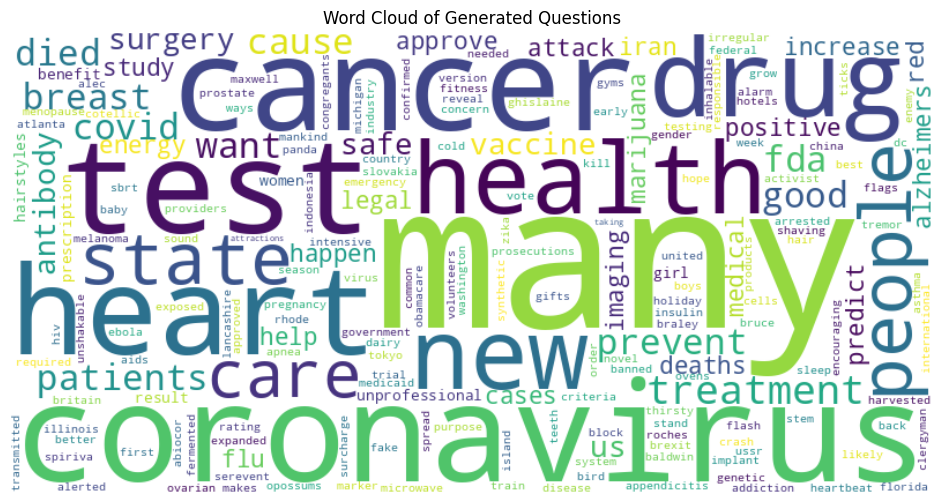

In [ ]:
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "is", "are", "was", "were",
    "do", "does", "did",
    "can", "could", "should",
    "has", "have", "had",
    "will", "would", "may", "might", "must"
])

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="viridis"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Generated Questions")
plt.show()

In [ ]:
def normalize_question(text):
    if not isinstance(text, str):
        text = str(text)

    text = text.lower()
    text = re.sub(r'\"+', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z\s?]', '', text)
    text = text.strip()

    return text

df_qg["question_normalized"] = df_qg["question"].apply(normalize_question)

df_qg.head()

,id,question,label,question_type,question_normalized
0,2,Is SBRT safe for prostate cancer patients?,mixture,yes/no,is sbrt safe for prostate cancer patients?
1,3,"Is a vaccine for breast, ovarian cancer safe?",true,yes/no,is a vaccine for breast ovarian cancer safe?
2,4,Is 'emergency' surgery required for appendicitis?,true,yes/no,is emergency surgery required for appendicitis?
3,5,Will Britain reveal trial criteria for coronav...,true,yes/no,will britain reveal trial criteria for coronav...
4,7,What does the U.S. stand for?,true,wh,what does the us stand for?
